In [1]:
# --- Core libraries ---
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import geopandas as gpd
from shapely.geometry import Point
from tabulate import tabulate
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

#--- Custom Functions as defined by the user ---
import sys
sys.path.append(os.path.abspath("../tools"))
import functions

In [15]:
df_raw = pd.read_csv("Groupdownsampling.csv") 


/tmp/ipykernel_65640/1747678292.py:1: DtypeWarning: Columns (6,7,12,13,14,15,16,17,20,22,23,24,26,28,29,30,31,32,39,40,42,43,47,48,49) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv("Groupdownsampling.csv")


In [16]:
functions.summarize_dataframe(df_raw)

| variable                                              | dtype   |   count |   pct_complete |   n_unique |
|-------------------------------------------------------|---------|---------|----------------|------------|
| id                                                    | int64   |   69430 |          100   |      69036 |
| gdp_per_capita                                        | int64   |   69430 |          100   |        496 |
| EvapS3                                                | float64 |   69430 |          100   |       1155 |
| EvapS2                                                | float64 |   69430 |          100   |       1155 |
| EvapS1                                                | float64 |   69430 |          100   |       1155 |
| Evap9                                                 | float64 |   69430 |          100   |       1155 |
| Evap8                                                 | float64 |   69430 |          100   |       1155 |
| Evap7                     

In [17]:
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', 1000)

df_raw["ahc_cluster"].value_counts()

ahc_cluster
2017002    7841
2018014    7254
2017005    6650
2018013    6642
2013007    4573
2014028    4573
2015012    4573
2018032    2836
2017014    1802
2017008    1525
2018028    1521
2019026    1443
2019029    1152
2020003     972
2019020     864
2016007     500
2020002     459
2018019     399
2019017     385
2017031     359
2016027     324
2016011     324
2005009     300
2016013     288
2005001     262
2019000     234
2019021     192
2018000     188
2010013     179
2009004     178
2011020     178
2006002     172
2008003     161
2019004     156
2020006     150
2018023     150
2017012     150
2012013     150
2014031     150
2013012     150
2019030     149
2016003     149
2005004     148
2015029     144
2013011     142
2014009     140
2015019     132
2016023     132
2016014     123
2008004     120
2016021     118
2011001     118
2019002     114
2014019     112
2010002     110
2014024     105
2015013     100
2015007      99
2009005      98
2015002      96
2015005      96
2014010     

In [18]:
groups_to_downsample = df_raw["ahc_cluster"].value_counts()


In [72]:
# Step 1: Identify clusters with ≥ 1000 rows
big_clusters = df_raw["ahc_cluster"].value_counts()
big_clusters = big_clusters[big_clusters >= 500].index  # just the cluster IDs

# Step 2: Filter rows in df_raw to include only those clusters
df_filtered = df_raw[df_raw["ahc_cluster"].isin(big_clusters)]


In [73]:
df_filtered["ahc_cluster"].value_counts()

ahc_cluster
2017002    7841
2018014    7254
2017005    6650
2018013    6642
2013007    4573
2014028    4573
2015012    4573
2018032    2836
2017014    1802
2017008    1525
2018028    1521
2019026    1443
2019029    1152
2020003     972
2019020     864
2016007     500
Name: count, dtype: int64

In [74]:
functions.summarize_dataframe(df_filtered)

| variable                                              | dtype   |   count |   pct_complete |   n_unique |
|-------------------------------------------------------|---------|---------|----------------|------------|
| id                                                    | int64   |   54721 |          100   |      54721 |
| Evap9                                                 | float64 |   54721 |          100   |        131 |
| EvapS2                                                | float64 |   54721 |          100   |        131 |
| EvapS3                                                | float64 |   54721 |          100   |        131 |
| EvapS4                                                | float64 |   54721 |          100   |        131 |
| EvapS5                                                | float64 |   54721 |          100   |        131 |
| EvapS6                                                | float64 |   54721 |          100   |        131 |
| EvapS7                    

In [75]:
# Step 1: Define the feature columns (drop the target + any IDs)
feature_cols = [col for col in df_filtered.columns if col not in ["Grain.yield..tons.ha.1.", "longitude_jittered", "latitude_jittered", "jitter_radius_km", "sowing_year"]]

# Step 2: Check for duplicates across just the feature columns
is_duplicate = df_filtered.duplicated(subset=feature_cols, keep=False)

# Step 3: Count and/or view them
n_duplicates = is_duplicate.sum()
print(f"Rows with repeated feature values (excluding target): {n_duplicates}")

Rows with repeated feature values (excluding target): 0


##### strategic downsampling

In [76]:
features = [
    "Pest.prescence....64","Treatment.type",
    "Soil.type", "Treatment_Category",
    "N_Category" ]

In [77]:
# Define how many rows per cluster to keep
n_keep = 500

# Count missing values in prioritized features
df_filtered['n_missing'] = df_filtered[features].isna().sum(axis=1)

# Sort by cluster and missingness
df_sorted = df_filtered.sort_values(by=['ahc_cluster', 'n_missing'])

# Group by AHC and take top N with fewest missing values per group
best_samples = (
    df_sorted
    .groupby('ahc_cluster', group_keys=False)
    .head(n_keep)
)

# Optional: drop helper column
best_samples = best_samples.drop(columns='n_missing')

/tmp/ipykernel_65640/154335750.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['n_missing'] = df_filtered[features].isna().sum(axis=1)


In [78]:
best_samples["ahc_cluster"].value_counts()

ahc_cluster
2013007    500
2014028    500
2015012    500
2016007    500
2017002    500
2017005    500
2017008    500
2017014    500
2018013    500
2018014    500
2018028    500
2018032    500
2019020    500
2019026    500
2019029    500
2020003    500
Name: count, dtype: int64

In [79]:
functions.summarize_dataframe(best_samples)

| variable                                              | dtype   |   count |   pct_complete |   n_unique |
|-------------------------------------------------------|---------|---------|----------------|------------|
| id                                                    | int64   |    8000 |          100   |       8000 |
| Evap9                                                 | float64 |    8000 |          100   |         71 |
| EvapS2                                                | float64 |    8000 |          100   |         71 |
| EvapS3                                                | float64 |    8000 |          100   |         71 |
| EvapS4                                                | float64 |    8000 |          100   |         71 |
| EvapS5                                                | float64 |    8000 |          100   |         71 |
| EvapS6                                                | float64 |    8000 |          100   |         71 |
| EvapS7                    

In [80]:
# Step 1: Find IDs in df_filtered that are NOT in best_samples
excluded_ids = df_filtered.loc[~df_filtered['id'].isin(best_samples['id']), 'id']

# Step 2: Filter df_raw to exclude those IDs
testdata = df_raw[~df_raw['id'].isin(excluded_ids)]

In [81]:
functions.summarize_dataframe(testdata)

| variable                                              | dtype   |   count |   pct_complete |   n_unique |
|-------------------------------------------------------|---------|---------|----------------|------------|
| id                                                    | int64   |   22709 |          100   |      22315 |
| gdp_per_capita                                        | int64   |   22709 |          100   |        486 |
| EvapS3                                                | float64 |   22709 |          100   |       1095 |
| EvapS2                                                | float64 |   22709 |          100   |       1095 |
| EvapS1                                                | float64 |   22709 |          100   |       1095 |
| Evap9                                                 | float64 |   22709 |          100   |       1095 |
| Evap8                                                 | float64 |   22709 |          100   |       1095 |
| Evap7                     

In [90]:
testdata.groupby(["AEZ"]).size()


AEZ
1     2453
2       75
3        8
5     1381
6      684
7     1304
8       26
9        6
10     488
11     226
12      67
13     693
14      10
16     593
17    2302
18      32
19      54
20    3119
21     123
25     200
26     388
27    8029
28     137
29     229
32      75
33       7
dtype: int64

In [91]:
testdata.to_csv("testdata.csv", index=False)

In [82]:
# Step 1: Define the feature columns (drop the target + any IDs)
feature_cols = [col for col in df_raw if col not in ["Grain.yield..tons.ha.1."]]

# Step 2: Check for duplicates across just the feature columns
is_duplicate = df_raw.duplicated(subset=feature_cols, keep=False)

# Step 3: Count and/or view them
n_duplicates = is_duplicate.sum()
print(f"Rows with repeated feature values (excluding target): {n_duplicates}")

Rows with repeated feature values (excluding target): 0


In [23]:
# Number of non-duplicate rows in df_raw (excluding repeated feature values)
n_non_duplicates = len(df_raw) - n_duplicates
print(f"Number of non-duplicate rows: {n_non_duplicates}")

Number of non-duplicate rows: 69430


In [24]:
# Get value counts of 'ahc_cluster' for non-duplicate rows in df_raw
df_raw.loc[~is_duplicate, "ahc_cluster"].value_counts()

ahc_cluster
2017002    7841
2018014    7254
2017005    6650
2018013    6642
2013007    4573
2014028    4573
2015012    4573
2018032    2836
2017014    1802
2017008    1525
2018028    1521
2019026    1443
2019029    1152
2020003     972
2019020     864
2016007     500
2020002     459
2018019     399
2019017     385
2017031     359
2016027     324
2016011     324
2005009     300
2016013     288
2005001     262
2019000     234
2019021     192
2018000     188
2010013     179
2009004     178
2011020     178
2006002     172
2008003     161
2019004     156
2020006     150
2018023     150
2017012     150
2012013     150
2014031     150
2013012     150
2019030     149
2016003     149
2005004     148
2015029     144
2013011     142
2014009     140
2015019     132
2016023     132
2016014     123
2008004     120
2016021     118
2011001     118
2019002     114
2014019     112
2010002     110
2014024     105
2015013     100
2015007      99
2009005      98
2015002      96
2015005      96
2014010     

In [83]:
# Step 1: Count cluster sizes
cluster_counts = testdata["ahc_cluster"].value_counts()

# Step 2: Identify clusters with >= 500 rows
large_clusters = cluster_counts[cluster_counts >= 500].index

# Step 3: Filter the dataframe
plotting_df = testdata[testdata["ahc_cluster"].isin(large_clusters)]

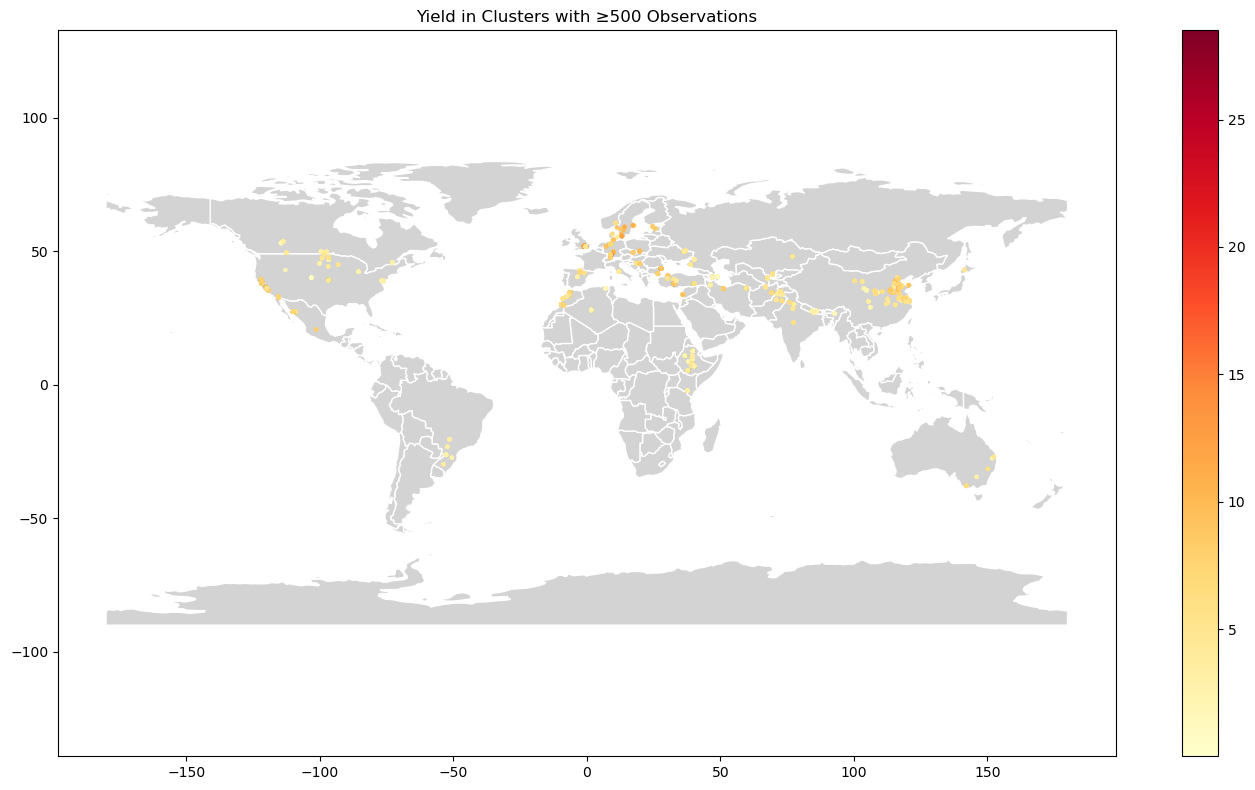

In [86]:
functions.plot_yield_by_region(
    df= testdata,
    coord_cols={
        'lat': 'Conversion.for.latitude',
        'lon': 'Conversion.for.longitude'
    },
    yield_col='Grain.yield..tons.ha.1.',
    bounds=None,
    title="Yield in Clusters with ≥500 Observations"
)

In [ ]:
df_raw.loc[~is_duplicate].to_csv("groupdownsampling.csv", index=False)